# pyMotorGeo - Motor DXF Geometry Analysis

전동기 DXF 도면 분석 및 지오메트리 처리를 위한 Python 패키지 개발 노트북

## Processing Workflow

| Step | 내용 | 핵심 함수 |
|------|------|-----------|
| **1** | 환경 설정 — 패키지 임포트 + DXF 경로 | - |
| **2** | DXF 읽기 — `all_entities` 로드 + motor_type 판별 | `read_entity_list()`, `classify_inner_outer_rotor()` |
| **3a** | 에어갭 탐지 — arc span 기반 (1주기 coverage 검증) | `find_airgap_by_arc_span()` |
| **3b** | Stator/Rotor 분리 — airgap 반경 기준 | - |
| **4** | 극수/슬롯수 판별 — 로터→극수, 스테이터→슬롯수 | `count_poles()`, `count_slots()` |
| **5** | **Half-Unit 추출** — 반극(rotor) + 반슬롯(stator) | `extract_half_pole_entities()`, `extract_half_slot_entities()` |
| **6** | 시각화 — 전체 / 반극 / 반슬롯 / 재구성 | `plot_entities()` |
| **7** | 로터 토폴로지 — SPM/IPM/SynRM 판별 | `classify_pole_topology()` |
| **8** | 기하 재구성 — half → mirror → circular array | `reconstruct_from_half()` |

---

### 핵심 원칙
> **Half-Unit (반극 + 반슬롯)이 최소 반복 단위(Minimum Repeating Unit)이다.**
> 
> 극과 슬롯은 각각 mirror symmetry를 가지므로,
> **반극(half-pole)**과 **반슬롯(half-slot)**이 모든 기하를 재구성할 수 있는 최소 고유 단위입니다.
> 
> `half-unit → mirror → 1 unit → circular array → full geometry`


In [9]:
# =============================================================================
# 1. 환경 설정 (Environment Setup)
# =============================================================================
%matplotlib widget

import sys
sys.path.insert(0, r"D:\KangDH\Emlab_emach\Class")  # pyMotorGeo 패키지 경로

import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Wedge, FancyArrow, Circle, Arc
from matplotlib.collections import PatchCollection, LineCollection
from matplotlib.lines import Line2D
from collections import defaultdict, Counter
import ezdxf
import ipywidgets as widgets
from IPython.display import display, clear_output

# pyMotorGeo 패키지 임포트 (개발 중 → 서브모듈 먼저 reload)
import importlib
import pyMotorGeo.core
import pyMotorGeo.reader
import pyMotorGeo.analysis_airgap
import pyMotorGeo.analysis_rotor
import pyMotorGeo.analysis_stator
import pyMotorGeo.analysis
import pyMotorGeo.topology
import pyMotorGeo.topology_rotor
import pyMotorGeo.topology_stator
import pyMotorGeo.pyleecan_bridge
import pyMotorGeo.gui_region
import pyMotorGeo.region_closing
importlib.reload(pyMotorGeo.core)
importlib.reload(pyMotorGeo.reader)
importlib.reload(pyMotorGeo.analysis_airgap)
importlib.reload(pyMotorGeo.analysis_rotor)
importlib.reload(pyMotorGeo.analysis_stator)
importlib.reload(pyMotorGeo.analysis)
importlib.reload(pyMotorGeo.topology)
importlib.reload(pyMotorGeo.topology_rotor)
importlib.reload(pyMotorGeo.topology_stator)
importlib.reload(pyMotorGeo.pyleecan_bridge)
importlib.reload(pyMotorGeo.gui_region)
importlib.reload(pyMotorGeo.region_closing)
import pyMotorGeo
importlib.reload(pyMotorGeo)

from pyMotorGeo import (
    EntityInfo,
    read_entity_list,
    find_origin_candidates,
    find_concentric_radii,
    classify_inner_outer_rotor,
    # 에어갭 + 분리
    split_stator_rotor_by_arc_span,
    # 극수/슬롯수 (entity 기반)
    count_poles,
    count_slots,
    # 극수/슬롯수 (닫힌 영역 기반 + 교차 검증)
    count_poles_by_regions,
    estimate_poles_robust,
    count_slots_by_regions,
    estimate_slots_robust,
    # 컨덕터 탐지
    detect_slot_conductors,
    # Topology (legacy)
    detect_circular_array_pattern,
    extract_single_pole_entities,
    extract_single_slot_entities,
    classify_pole_topology,
    analyze_rotor_topology,
    # Half-Unit (최소 반복 단위)
    extract_half_pole_entities,
    extract_half_slot_entities,
    reconstruct_from_half,
    # Core transforms
    rotate_entity,
    mirror_entity,
    # ── v1.3: 분리 토폴로지 + 영역 분류 ──
    classify_rotor_entities,
    reassign_rotor_region,
    get_rotor_region_summary,
    ROTOR_REGION_NAMES,
    ROTOR_REGION_COLORS,
    classify_stator_entities,
    reassign_stator_region,
    get_stator_region_summary,
    STATOR_REGION_NAMES,
    STATOR_REGION_COLORS,
    # pyleecan 브릿지
    check_pyleecan_available,
    extract_dimensions_from_dxf,
    create_pyleecan_machine,
    dims_to_summary,
    # ── v1.5.1: 닫힌 영역(face) 기반 시각화 + face 탐지 ──
    FaceRegionGUI,
    FaceRegionGUILite,
    create_radial_line,
    create_arc_boundary,
    close_rotor_period,
    close_stator_period,
    close_period_model,
    # v1.5.1: 1극/1슬롯 단위 close (권장)
    close_one_pole,
    close_one_slot,
    detect_closed_faces,
    auto_name_faces,
    get_face_summary,
    plot_faces_static,
    FACE_REGION_NAMES,
    FACE_REGION_COLORS,
)

# ═══════════════════════════════════════════════════════════════
# DXF 입력 설정
# ═══════════════════════════════════════════════════════════════
INPUT_MODE = 'combined'  # 'combined' | 'separate' | 'stator_only' | 'rotor_only'

combined_dxf_path = r"E:\KDH\AdaptiveTemplate\TestCAD1.dxf"
stator_dxf_path   = r"E:\KDH\KJS\C688\Moasoft C588_CAD.dxf"
rotor_dxf_path    = r"E:\KDH\KJS\C688\Moasoft C588_CAD_RT.dxf"

print(f"pyMotorGeo 패키지 로드 완료 (v{pyMotorGeo.__version__})")
print(f"입력 모드: {INPUT_MODE}")

AttributeError: module 'pyMotorGeo' has no attribute 'core'

## 2. DXF 읽기 테스트

pyMotorGeo 패키지의 `read_entity_list()` 함수로 DXF 파일을 읽고 엔티티 정보를 확인합니다.

- INSERT/BLOCK 확장 지원
- TEXT/MTEXT 등 불필요한 엔티티 자동 필터링

In [2]:
# =============================================================================
# 2. DXF 읽기 (입력 모드에 따라 처리)
# =============================================================================

stator_entities = []
rotor_entities = []
doc = None
rotor_doc = None

if INPUT_MODE == 'combined':
    # 통합 DXF: 스테이터+로터가 하나의 파일에 있음
    all_entities, doc = read_entity_list(combined_dxf_path, expand_inserts=True)
    print(f"통합 DXF 로드: {len(all_entities)} entities")
    
    # 내/외전형 판별 후 에어갭 기준으로 분리
    origin = (0.0, 0.0)
    motor_type = classify_inner_outer_rotor(all_entities, origin)
    
    # 에어갭 반경 추정 (동심원 분석 기반)
    concentric = find_concentric_radii(all_entities, origin)
    if len(concentric) >= 2:
        gaps = [(concentric[i+1] - concentric[i], i) for i in range(len(concentric)-1)]
        min_gap, airgap_idx = min(gaps, key=lambda x: x[0])
        airgap_r = (concentric[airgap_idx] + concentric[airgap_idx+1]) / 2
    else:
        airgap_r = np.median([ei.r_max for ei in all_entities])
    
    print(f"  모터 타입: {motor_type}, 에어갭 반경: {airgap_r:.2f}")
    
    # 에어갭 기준으로 스테이터/로터 분리
    if motor_type == 'inner_rotor':
        stator_entities = [ei for ei in all_entities if ei.r_min > airgap_r * 0.9]
        rotor_entities = [ei for ei in all_entities if ei.r_max < airgap_r * 1.1]
    else:  # outer_rotor
        stator_entities = [ei for ei in all_entities if ei.r_max < airgap_r * 1.1]
        rotor_entities = [ei for ei in all_entities if ei.r_min > airgap_r * 0.9]
    
    print(f"  스테이터: {len(stator_entities)}, 로터: {len(rotor_entities)} entities")

elif INPUT_MODE == 'separate':
    # 별도 DXF: 스테이터/로터가 각각 다른 파일
    stator_entities, doc = read_entity_list(stator_dxf_path, expand_inserts=True)
    rotor_entities, rotor_doc = read_entity_list(rotor_dxf_path, expand_inserts=True)
    print(f"스테이터 DXF: {len(stator_entities)} entities")
    print(f"로터 DXF: {len(rotor_entities)} entities")

elif INPUT_MODE == 'stator_only':
    # 스테이터만 있는 DXF
    stator_entities, doc = read_entity_list(stator_dxf_path, expand_inserts=True)
    print(f"스테이터 DXF: {len(stator_entities)} entities (로터 없음)")

elif INPUT_MODE == 'rotor_only':
    # 로터만 있는 DXF
    rotor_entities, rotor_doc = read_entity_list(rotor_dxf_path, expand_inserts=True)
    print(f"로터 DXF: {len(rotor_entities)} entities (스테이터 없음)")

else:
    raise ValueError(f"Unknown INPUT_MODE: {INPUT_MODE}")

# 엔티티 타입 요약 출력
if stator_entities:
    stator_types = Counter(ei.etype for ei in stator_entities)
    print(f"\n스테이터 엔티티 타입: {dict(stator_types)}")

if rotor_entities:
    rotor_types = Counter(ei.etype for ei in rotor_entities)
    print(f"로터 엔티티 타입: {dict(rotor_types)}")

[read_entity_list] 2208 entities loaded from E:\KDH\AdaptiveTemplate\TestCAD1.dxf
  Entity types: {'ARC': 560, 'LINE': 1648}
  _MotorCAD0_                     1
  _MotorCAD1_                     1
  _MotorCAD2_                     1
  _MotorCAD3_                     1
  _MotorCAD4_                     1
  _MotorCAD5_                     1
  _MotorCAD6_                     1
  _MotorCAD7_                     1
  _MotorCAD8_                     1
  _MotorCAD9_                     1
통합 DXF 로드: 2208 entities
[classify] radial LINE count: 752
[classify] slot walls: inner_avg=75.6, outer_avg=79.0, slot_center=77.3
[classify] model radius range: [23.5, 99.0], mid=61.2
[classify] → slot center OUTER → inner_rotor
  모터 타입: inner_rotor, 에어갭 반경: 51.85
  스테이터: 2200, 로터: 136 entities

스테이터 엔티티 타입: {'ARC': 552, 'LINE': 1648}
로터 엔티티 타입: {'ARC': 72, 'LINE': 64}


In [6]:
# 통합 DXF: 스테이터+로터가 하나의 파일에 있음
all_entities, doc = read_entity_list(combined_dxf_path, expand_inserts=True)
# print(f"통합 DXF 로드: {len(all_entities)} entities")

# 내/외전형 판별 후 에어갭 기준으로 분리
origin = (0.0, 0.0)
motor_type = classify_inner_outer_rotor(all_entities, origin)


NameError: name 'read_entity_list' is not defined

In [5]:
# =============================================================================
# 3. Stator / Rotor 분리 (arc_span 에어갭 기반)
# =============================================================================
split_result = split_stator_rotor_by_arc_span(
    all_entities, origin,
    motor_type=motor_type,
    verbose=True,
)

stator_entities = split_result['stator']
rotor_entities  = split_result['rotor']
airgap_r_inner  = split_result['airgap_r_inner']
airgap_r_outer  = split_result['airgap_r_outer']
airgap_r        = split_result['airgap_r_mid']

# 엔티티 타입 요약
for label, ents in [('Stator', stator_entities), ('Rotor', rotor_entities)]:
    if ents:
        types = Counter(ei.etype for ei in ents)
        print(f"  {label} 타입: {dict(types)}")

NameError: name 'split_stator_rotor_by_arc_span' is not defined

In [5]:
# # 전체 반경별 상세 정보
# print(f"{'radius':>10} | {'n_arcs':>6} | {'avg_span':>8} | {'cov_period':>10} | {'cov_360':>8}")
# print("-" * 56)
# for ri in result['radii_info']:
#     marker = " ★" if any(abs(ri['radius'] - cc['radius']) < 0.2 
#                          for cc in result['core_candidates']) else ""
#     print(f"{ri['radius']:>10.3f} | {ri['n_arcs']:>6} | {ri['avg_span_deg']:>7.1f}° | "
#           f"{ri['coverage_period']:>10.4f} | {ri['coverage_360']:>7.4f}{marker}")


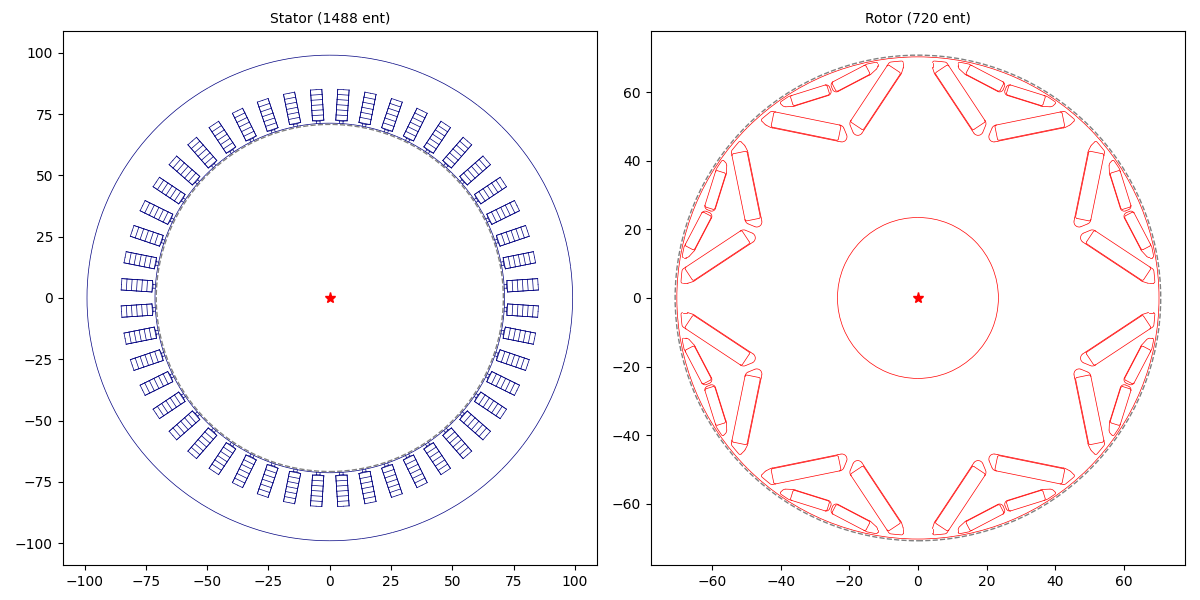

In [6]:
# Stator / Rotor 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, ents, title, color in [
    (axes[0], stator_entities, f"Stator ({len(stator_entities)} ent)", 'navy'),
    (axes[1], rotor_entities,  f"Rotor ({len(rotor_entities)} ent)",  'red'),
]:
    for ei in ents:
        if ei.etype == 'LINE' and ei.points:
            xs, ys = zip(*ei.points)
            ax.plot(xs, ys, color=color, lw=0.5)
        elif ei.etype == 'ARC' and ei.center and ei.radius:
            ax.add_patch(Arc(ei.center, 2*ei.radius, 2*ei.radius,
                            theta1=ei.start_angle or 0, theta2=ei.end_angle or 360,
                            color=color, lw=0.5))
    ax.add_patch(Circle(origin, airgap_r, fill=False, color='gray', lw=1, ls='--'))
    ax.plot(*origin, 'r*', ms=8)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=10)
plt.tight_layout()
plt.show()


In [8]:
# =============================================================================
# 4. 극수 / 슬롯수 판별 (강건 추정 — confidence 우선)
# =============================================================================
n_poles = None
n_slots = None
pole_pitch_deg = None
slot_pitch_deg = None

# ── A. 극수 판별 (로터) ──
print("=" * 60)
print("극수 판별 (Rotor)")
print("=" * 60)
if rotor_entities:
    # 1) Circular Array Pattern (topology 모듈) — 참고용
    pattern_result = detect_circular_array_pattern(rotor_entities, origin, min_repeats=4)
    if pattern_result['has_pattern']:
        print(f"[Circular Array] 극수 = {pattern_result['n_poles']}, "
              f"극 피치 = {pattern_result['pole_pitch_deg']:.2f}° (참고)")

    # 2) Robust estimation (confidence 우선 선택)
    poles_robust = estimate_poles_robust(
        rotor_entities, origin,
        airgap_r_inner=airgap_r_inner,
        verbose=True,
    )

    # 최종 극수 결정: robust 결과 (high-confidence 우선)
    if poles_robust['n_poles'] > 0:
        n_poles = poles_robust['n_poles']
        pole_pitch_deg = 360.0 / n_poles
    else:
        # fallback: circular_array
        if pattern_result['has_pattern']:
            n_poles = pattern_result['n_poles']
            pole_pitch_deg = pattern_result['pole_pitch_deg']
        else:
            print("극수 판별 실패")
else:
    print("로터 엔티티 없음 → 극수 판별 건너뜀")

# ── B. 슬롯수 판별 (스테이터) ──
print(f"\n{'=' * 60}")
print("슬롯수 판별 (Stator)")
print("=" * 60)
if stator_entities:
    slots_robust = estimate_slots_robust(
        stator_entities, origin,
        airgap_r_outer=airgap_r_outer,
        verbose=True,
    )
    if slots_robust['n_slots'] > 0:
        n_slots = slots_robust['n_slots']
        slot_pitch_deg = 360.0 / n_slots
else:
    print("스테이터 엔티티 없음 → 슬롯수 판별 건너뜀")

# ── C. 컨덕터 탐지 (스테이터 슬롯 내 반복 객체) ──
print(f"\n{'=' * 60}")
print("컨덕터 탐지 (Stator)")
print("=" * 60)
conductor_result = None
if stator_entities and n_slots:
    r_outer_max = max(ei.r_max for ei in stator_entities)
    conductor_result = detect_slot_conductors(
        stator_entities, origin,
        n_slots=n_slots,
        slot_pitch_deg=slot_pitch_deg,
        airgap_r_outer=airgap_r_outer,
        r_outer_max=r_outer_max,
        verbose=True,
    )

# ── 요약 ──
print(f"\n{'=' * 60}")
print(f"극수(Poles)   : {n_poles}")
print(f"슬롯수(Slots) : {n_slots}")
if n_poles and n_slots:
    print(f"슬롯/극/상    : {n_slots / n_poles / 3:.4f}  (SPP)")
print(f"에어갭        : {airgap_r_inner:.3f} ~ {airgap_r_outer:.3f} mm")
if conductor_result and conductor_result['has_conductors']:
    print(f"컨덕터/슬롯   : {conductor_result['conductors_per_slot']}개")
    print(f"전체 컨덕터   : {conductor_result['total_conductors']}개")
print(f"{'=' * 60}")

극수 판별 (Rotor)
[Circular Array] 극수 = 42, 극 피치 = 8.62° (참고)
[poles_robust] 방법별 결과:
  arc_distribution: 60극 (conf=medium)
  arc_group_r23.5: 8극 (conf=high) ★
  → 최종: 8극, agreement=False

슬롯수 판별 (Stator)
[slots_robust] 방법별 결과:
  radial_line: 24슬롯 (conf=medium)
  arc_array_r99.0: 48슬롯 (conf=high) ★
  → 최종: 48슬롯, agreement=False

컨덕터 탐지 (Stator)
[detect_conductors] 닫힌 폴리라인 없음 → 컨덕터 탐지 불가

극수(Poles)   : 8
슬롯수(Slots) : 48
슬롯/극/상    : 2.0000  (SPP)
에어갭        : 70.270 ~ 71.270 mm


## 5. Half-Unit 추출 (반극 + 반슬롯)

극수·슬롯수 + arc_span 에어갭을 바탕으로 **반극(half-pole)**과 **반슬롯(half-slot)**을 추출합니다.

- `all_entities` → `airgap_r` 기준 stator/rotor 분리 → 각각 반극/반슬롯 추출
- `extract_half_pole_entities()` : `[0°, pole_pitch/2]` 범위 로터 엔티티
- `extract_half_slot_entities()` : `[0°, slot_pitch/2]` 범위 스테이터 엔티티
- 추출 후 **0°** 기준으로 정규화, `mirror_axis_deg`에서 대칭하면 1단위 복원


In [9]:
rotor_entities

[EntityInfo(etype='ARC', layer='_MotorCAD550_', points=[(-70.27, 8.60559305760845e-15), (-49.6883935139787, -49.68839351397869), (-64.92101474956813, -26.89116479229485)], radius=70.27, center=(0.0, 0.0), start_angle=180.0, end_angle=225.0, is_closed=False),
 EntityInfo(etype='ARC', layer='_MotorCAD551_', points=[(-49.6883935139787, -49.68839351397869), (-1.2908389586412676e-14, -70.27), (-26.891164792294838, -64.92101474956813)], radius=70.27, center=(0.0, 0.0), start_angle=225.0, end_angle=270.0, is_closed=False),
 EntityInfo(etype='ARC', layer='_MotorCAD552_', points=[(-1.2908389586412676e-14, -70.27), (49.68839351397868, -49.6883935139787), (26.891164792294873, -64.9210147495681)], radius=70.27, center=(0.0, 0.0), start_angle=270.0, end_angle=315.0, is_closed=False),
 EntityInfo(etype='ARC', layer='_MotorCAD553_', points=[(49.68839351397868, -49.6883935139787), (70.27, 0.0), (-64.92101474956812, 26.891164792294866)], radius=70.27, center=(0.0, 0.0), start_angle=315.0, end_angle=0.0

In [10]:
half_pole['concentric_arcs']


NameError: name 'half_pole' is not defined

In [11]:
# =============================================================================
# 5. Half-Unit 추출 (반극 + 반슬롯)
#    기준: 0° (x축 오른쪽), mirror축 = pitch/2 (극수/슬롯수에서 명시 계산)
# =============================================================================
half_pole = None
half_slot = None

# ── 반극 추출 (로터) ──
if rotor_entities and pole_pitch_deg:
    half_pole = extract_half_pole_entities(
        rotor_entities, origin,
        pole_pitch_deg=pole_pitch_deg,
        reference_angle=0.0,        # 0° = x축 오른쪽
        normalize_to_zero=True,
    )
    hp_deg = half_pole['half_pitch_deg']
    n_ent = len(half_pole['normalized_entities'])
    n_conc = len(half_pole['concentric_arcs'])
    print(f"반극(Half-Pole) 추출 완료:")
    print(f"  반극 범위: [0°, {hp_deg:.2f}°]")
    print(f"  반극 피치: {hp_deg:.2f}° (= {pole_pitch_deg:.2f}° / 2)")
    print(f"  mirror 축: {half_pole['mirror_axis_deg']:.2f}°  (= pole_pitch/2)")
    print(f"  엔티티: {n_ent}개 + 동심원 {n_conc}개")
    print(f"  극수: {half_pole['n_poles']}")
else:
    print("로터 엔티티 또는 극 피치 없음 → 반극 추출 건너뜀")

print()

# ── 반슬롯 추출 (스테이터) ──
if stator_entities and slot_pitch_deg:
    half_slot = extract_half_slot_entities(
        stator_entities, origin,
        slot_pitch_deg=slot_pitch_deg,
        n_slots=n_slots,
        reference_angle=0.0,        # 0° = x축 오른쪽
        normalize_to_zero=True,
    )
    hs_deg = half_slot['half_pitch_deg']
    n_ent = len(half_slot['normalized_entities'])
    n_conc = len(half_slot['concentric_arcs'])
    print(f"반슬롯(Half-Slot) 추출 완료:")
    print(f"  반슬롯 범위: [0°, {hs_deg:.2f}°]")
    print(f"  반슬롯 피치: {hs_deg:.2f}° (= {slot_pitch_deg:.2f}° / 2)")
    print(f"  mirror 축: {half_slot['mirror_axis_deg']:.2f}°  (= slot_pitch/2)")
    print(f"  엔티티: {n_ent}개 + 동심원 {n_conc}개")
    print(f"  슬롯수: {half_slot['n_slots']}")
else:
    print("스테이터 엔티티 또는 슬롯 피치 없음 → 반슬롯 추출 건너뜀")

반극(Half-Pole) 추출 완료:
  반극 범위: [0°, 22.50°]
  반극 피치: 22.50° (= 45.00° / 2)
  mirror 축: 22.50°  (= pole_pitch/2)
  엔티티: 42개 + 동심원 48개
  극수: 8

반슬롯(Half-Slot) 추출 완료:
  반슬롯 범위: [0°, 3.75°]
  반슬롯 피치: 3.75° (= 7.50° / 2)
  mirror 축: 3.75°  (= slot_pitch/2)
  엔티티: 17개 + 동심원 192개
  슬롯수: 48


## 6. Interactive Visualization

드롭다운으로 뷰를 선택하고, 체크박스로 레이어를 토글합니다.  
`%matplotlib widget` — 마우스로 **zoom / pan** 가능.

In [ ]:
# =============================================================================
# 6. Interactive Visualization (ipywidgets + %matplotlib widget)
# =============================================================================

def _draw_entities(ax, entities, origin, color='blue', lw=0.5):
    """EntityInfo 리스트를 ax에 그립니다."""
    ox, oy = origin
    for ei in entities:
        if ei.etype == 'LINE' and ei.points:
            xs, ys = zip(*ei.points)
            ax.plot(xs, ys, color=color, lw=lw)
        elif ei.etype == 'ARC' and ei.center and ei.radius:
            ax.add_patch(Arc(ei.center, 2*ei.radius, 2*ei.radius,
                             theta1=ei.start_angle or 0,
                             theta2=ei.end_angle or 360,
                             color=color, lw=lw))
        elif ei.etype == 'CIRCLE' and ei.center and ei.radius:
            ax.add_patch(Circle(ei.center, ei.radius,
                                fill=False, color=color, lw=lw))
        elif ei.etype in ('LWPOLYLINE', 'POLYLINE', 'SPLINE') and ei.points:
            xs, ys = zip(*ei.points)
            if ei.is_closed:
                ax.fill(xs, ys, alpha=0.15, color='green')
            ax.plot(xs, ys, color='green', lw=lw)

# ── 데이터 준비 (1극/1슬롯/주기모델 재구성) ──
one_pole_ents = reconstruct_from_half(half_pole, origin, n_repeats=1) if half_pole else []
one_slot_ents = reconstruct_from_half(half_slot, origin, n_repeats=1) if half_slot else []
full_recon_rotor  = reconstruct_from_half(half_pole, origin, n_repeats=n_poles) if half_pole else []
full_recon_stator = reconstruct_from_half(half_slot, origin, n_repeats=n_slots) if half_slot else []

# 주기모델: GCD(n_poles, n_slots) 기반 최소 주기
from math import gcd
n_period = gcd(n_poles, n_slots) if (n_poles and n_slots) else 1
period_deg = 360.0 / n_period if n_period else 360.0
poles_per_period = n_poles // n_period if n_period else n_poles
slots_per_period = n_slots // n_period if n_period else n_slots
period_rotor = reconstruct_from_half(half_pole, origin, n_repeats=poles_per_period) if half_pole else []
period_stator = reconstruct_from_half(half_slot, origin, n_repeats=slots_per_period) if half_slot else []

print(f"주기모델: {period_deg:.1f}° (GCD={n_period}, {poles_per_period}극/{slots_per_period}슬롯)")

# ── 위젯 생성 ──
view_dropdown = widgets.Dropdown(
    options=[
        ('전체 도면 (Stator + Rotor)', 'full'),
        ('Half-Pole (반극)', 'half_pole'),
        ('1 Pole (1극 재구성)', 'one_pole'),
        ('Half-Slot (반슬롯)', 'half_slot'),
        ('1 Slot (1슬롯 재구성)', 'one_slot'),
        (f'주기모델 ({period_deg:.0f}°)', 'period'),
        ('360° 재구성', 'recon_360'),
        ('Half-Unit 확대 (반극 + 반슬롯)', 'half_unit'),
    ],
    value='full',
    description='View:',
    layout=widgets.Layout(width='380px'),
)
chk_stator  = widgets.Checkbox(value=True,  description='Stator',  indent=False)
chk_rotor   = widgets.Checkbox(value=True,  description='Rotor',   indent=False)
chk_airgap  = widgets.Checkbox(value=True,  description='Airgap',  indent=False)
chk_wedge   = widgets.Checkbox(value=True,  description='Wedge',   indent=False)
chk_mirror  = widgets.Checkbox(value=True,  description='Mirror Axis', indent=False)

controls_box = widgets.HBox([
    view_dropdown,
    widgets.VBox([chk_stator, chk_rotor]),
    widgets.VBox([chk_airgap, chk_wedge, chk_mirror]),
])

fig_out = widgets.Output()

def _update_plot(*_):
    view = view_dropdown.value
    with fig_out:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8, 8))

        title_str = ''

        if view == 'full':
            title_str = f'전체 도면 ({len(stator_entities) + len(rotor_entities)} ent)'
            if chk_stator.value:
                _draw_entities(ax, stator_entities, origin, 'navy', 0.5)
            if chk_rotor.value:
                _draw_entities(ax, rotor_entities, origin, 'red', 0.5)

        elif view == 'half_pole' and half_pole:
            hp = half_pole['normalized_entities']
            hp_d = half_pole['half_pitch_deg']
            title_str = f'Half-Pole ({len(hp)} ent, {hp_d:.1f}°)'
            _draw_entities(ax, hp, origin, 'red', 0.8)
            # air barrier ARC 등 원본 arc도 함께 그림
            if 'concentric_arcs' in half_pole:
                _draw_entities(ax, half_pole['concentric_arcs'], origin, 'orange', 1.2)
            r_m = max((ei.r_max for ei in hp), default=30)
            if chk_wedge.value:
                ax.add_patch(Wedge(origin, r_m*1.05, 0, hp_d,
                                   alpha=0.08, color='red'))
            if chk_mirror.value:
                mx = r_m*1.1*math.cos(math.radians(hp_d))
                my = r_m*1.1*math.sin(math.radians(hp_d))
                ax.plot([0, mx], [0, my], 'r--', lw=1, label=f'mirror {hp_d:.1f}°')
                ax.legend(fontsize=7)

        elif view == 'one_pole' and one_pole_ents:
            ppd = pole_pitch_deg
            title_str = f'1 Pole ({len(one_pole_ents)} ent, {ppd:.1f}°)'
            _draw_entities(ax, one_pole_ents, origin, 'darkred', 0.8)
            r_m = max((ei.r_max for ei in one_pole_ents), default=30)
            if chk_wedge.value:
                ax.add_patch(Wedge(origin, r_m*1.05, 0, float(ppd),
                                   alpha=0.08, color='darkred'))

        elif view == 'half_slot' and half_slot:
            hs = half_slot['normalized_entities']
            hs_d = half_slot['half_pitch_deg']
            title_str = f'Half-Slot ({len(hs)} ent, {hs_d:.1f}°)'
            _draw_entities(ax, hs, origin, 'navy', 0.8)
            r_m = max((ei.r_max for ei in hs), default=60)
            if chk_wedge.value:
                ax.add_patch(Wedge(origin, r_m*1.05, 0, hs_d,
                                   alpha=0.08, color='navy'))
            if chk_mirror.value:
                mx = r_m*1.1*math.cos(math.radians(hs_d))
                my = r_m*1.1*math.sin(math.radians(hs_d))
                ax.plot([0, mx], [0, my], 'b--', lw=1, label=f'mirror {hs_d:.1f}°')
                ax.legend(fontsize=7)

        elif view == 'one_slot' and one_slot_ents:
            spd = slot_pitch_deg
            title_str = f'1 Slot ({len(one_slot_ents)} ent, {spd:.1f}°)'
            _draw_entities(ax, one_slot_ents, origin, 'darkblue', 0.8)
            r_m = max((ei.r_max for ei in one_slot_ents), default=60)
            if chk_wedge.value:
                ax.add_patch(Wedge(origin, r_m*1.05, 0, spd,
                                   alpha=0.08, color='darkblue'))

        elif view == 'period':
            n_total = len(period_rotor) + len(period_stator)
            title_str = f'주기모델 {period_deg:.0f}° ({n_total} ent, {poles_per_period}P/{slots_per_period}S)'
            if chk_rotor.value:
                _draw_entities(ax, period_rotor, origin, 'darkred', 0.6)
            if chk_stator.value:
                _draw_entities(ax, period_stator, origin, 'darkblue', 0.6)
            # 주기 경계선
            r_m = max(
                max((ei.r_max for ei in period_stator), default=60),
                max((ei.r_max for ei in period_rotor), default=30),
            )
            if chk_wedge.value:
                ax.add_patch(Wedge(origin, r_m*1.05, 0, period_deg,
                                   alpha=0.04, color='gray'))
                mx0 = r_m*1.08
                ax.plot([0, mx0], [0, 0], 'k--', lw=0.8, alpha=0.5)
                mx1 = r_m*1.08*math.cos(math.radians(period_deg))
                my1 = r_m*1.08*math.sin(math.radians(period_deg))
                ax.plot([0, mx1], [0, my1], 'k--', lw=0.8, alpha=0.5)

        elif view == 'recon_360':
            n_total = len(full_recon_rotor) + len(full_recon_stator)
            title_str = f'360° 재구성 ({n_total} ent)'
            if chk_rotor.value:
                _draw_entities(ax, full_recon_rotor, origin, 'darkred', 0.4)
            if chk_stator.value:
                _draw_entities(ax, full_recon_stator, origin, 'darkblue', 0.4)

        elif view == 'half_unit':
            title_str = 'Half-Unit 확대'
            if half_pole:
                hp = half_pole['normalized_entities']
                _draw_entities(ax, hp, origin, 'red', 1.0)
                r_m = max((ei.r_max for ei in hp), default=30)
                if chk_wedge.value:
                    ax.add_patch(Wedge(origin, r_m*1.05, 0,
                                       half_pole['half_pitch_deg'],
                                       alpha=0.05, color='red',
                                       label=f"half-pole {half_pole['half_pitch_deg']:.1f}°"))
            if half_slot:
                hs = half_slot['normalized_entities']
                _draw_entities(ax, hs, origin, 'navy', 1.0)
            if chk_wedge.value:
                ax.legend(fontsize=7)

        # 공통
        if chk_airgap.value and view in ('full', 'recon_360', 'period'):
            ax.add_patch(Circle(origin, float(airgap_r),
                                fill=False, color='gray', lw=1, ls='--'))
        ax.plot(*origin, 'r*', ms=6)
        ax.set_aspect('equal')
        ax.set_title(title_str, fontsize=10)
        fig.tight_layout()
        plt.show()

# ── 이벤트 바인딩 ──
for w in [view_dropdown, chk_stator, chk_rotor, chk_airgap, chk_wedge, chk_mirror]:
    w.observe(_update_plot, names='value')

display(controls_box, fig_out)
_update_plot()  # 초기 렌더링

주기모델: 45.0° (GCD=8, 1극/6슬롯)


Output()

## 7. 로터 토폴로지 분석 (1극 재구성 기준)

1극(1 Pole) 재구성 엔티티를 기반으로 토폴로지를 분류합니다.
- SPM / IPM / SynRM / PMa-SynRM 판별
- 반극(half-pole)은 열린 영역 때문에 분류 오류 → **1극 재구성** 후 판별

In [ ]:
# =============================================================================
# 7. 로터/스테이터 토폴로지 분석 (v1.3 — 분리 모듈)
#    classify_rotor_entities + classify_stator_entities
# =============================================================================
rotor_topo = None
stator_topo = None

# ── 로터 토폴로지 ──
if half_pole and one_pole_ents:
    # 1극 재구성 엔티티 → Dict list 변환
    one_pole_items = [
        {'entity': ei, 'original_angle': 0.0, 'relative_angle': 0.0}
        for ei in one_pole_ents
    ]
    # 내전형이므로 airgap_r = 로터 외경 = airgap_r_inner (70.27)
    rotor_topo = classify_rotor_entities(
        one_pole_items, origin,
        airgap_r=float(airgap_r_inner),   # ★ 로터 외경
        pole_pitch_deg=pole_pitch_deg,
        verbose=True,
    )
    print("=" * 60)
    print(f"[ROTOR] 토폴로지 분석 (1극 재구성, {pole_pitch_deg:.1f}°)")
    print("=" * 60)
    print(f"  ★ 토폴로지  : {rotor_topo['topology']}")
    print(f"  상세         : {rotor_topo['detail']}")
    print(f"  논리 자석    : {rotor_topo['n_magnets']}개 (클러스터)")
    print(f"  자석 엔티티  : {rotor_topo['n_magnet_entities']}개")
    print(f"  배리어       : {rotor_topo['n_barriers']}개")
    print(f"  표면 자석    : {rotor_topo['magnet_near_surface']}")
    print(f"  매입 자석    : {rotor_topo['magnet_embedded']}")
    print(f"  영역 요약    : {get_rotor_region_summary(rotor_topo['regions'])}")
else:
    print("[ROTOR] 1극 재구성 데이터 없음 → 건너뜀")

print()

# ── 스테이터 토폴로지 ──
if half_slot and one_slot_ents:
    one_slot_items = [
        {'entity': ei, 'original_angle': 0.0, 'relative_angle': 0.0}
        for ei in one_slot_ents
    ]
    # 스테이터 내경 = airgap_r_outer (71.27)
    # 스테이터 외경 = 최대 반경
    r_stator_outer = max((ei.r_max for ei in stator_entities), default=110)
    stator_topo = classify_stator_entities(
        one_slot_items, origin,
        airgap_r=float(airgap_r_outer),    # ★ 스테이터 내경
        r_outer=r_stator_outer,
        slot_pitch_deg=slot_pitch_deg,
        verbose=True,
    )
    print("=" * 60)
    print(f"[STATOR] 토폴로지 분석 (1슬롯 재구성, {slot_pitch_deg:.1f}°)")
    print("=" * 60)
    print(f"  상세         : {stator_topo['detail']}")
    print(f"  슬롯 영역    : {stator_topo['n_slot_regions']}개")
    print(f"  컨덕터 영역  : {stator_topo['n_conductor_regions']}개")
    print(f"  영역 요약    : {get_stator_region_summary(stator_topo['regions'])}")
else:
    print("[STATOR] 1슬롯 재구성 데이터 없음 → 건너뜀")

### 7-1. 닫힌 영역(Face) 기반 영역 할당 GUI — 로터
주기모델에 경계선 추가 → planar graph → 닫힌 면(face) 탐지 → 자동 이름 → **클릭 GUI로 재지정**.  
pyleecan의 SurfLine + label 개념 참고: **닫힌 영역 단위**로 이름(region)을 할당합니다.

In [ ]:
# =============================================================================
# 7-1. 닫힌 영역(Face) — 1극 단위 close (v1.5.1 권장 워크플로우)
#      half-pole → 1 pole → close_one_pole → detect_faces → GUI
# =============================================================================

# 핵심 반경
r_shaft = min((ei.r_min for ei in rotor_entities if ei.r_min > 0), default=23.0)
r_rotor_outer = float(airgap_r_inner)   # 70.27
r_stator_inner = float(airgap_r_outer)  # 71.27
r_stator_outer_val = max((ei.r_max for ei in stator_entities), default=99.0)

print(f"경계 반경:")
print(f"  Shaft        : {r_shaft:.2f} mm")
print(f"  Rotor outer  : {r_rotor_outer:.2f} mm")
print(f"  Stator inner : {r_stator_inner:.2f} mm")
print(f"  Stator outer : {r_stator_outer_val:.2f} mm")
print(f"  Pole pitch   : {pole_pitch_deg:.2f}°")
print(f"  Slot pitch   : {slot_pitch_deg:.2f}°")
print()

# ── 1극 재구성 (half-pole → mirror → 1 pole) ──
# 이미 extract_half_pole_entities + reconstruct_from_half로 생성됨
print(f"1극 재구성: {len(one_pole_ents)}개 엔티티")

# ── 1극 닫기 (close_one_pole) ──
pole_result = close_one_pole(
    one_pole_ents, origin,
    pole_pitch_deg=pole_pitch_deg,
    r_shaft=r_shaft,
    r_rotor_outer=r_rotor_outer,
)
print(f"1극 경계선: {len(pole_result['boundaries'])}개 추가")
print()

# ── 로터 face 탐지 + 자동 이름 ──
rotor_faces = detect_closed_faces(
    pole_result['closed_entities'], origin, min_area=1.0)
auto_name_faces(rotor_faces, r_shaft, r_rotor_outer,
                r_stator_inner, r_stator_outer_val,
                rotor_topology='SPM')

print(f"로터 닫힌 영역 (1극): {len(rotor_faces)}개")
for i, fi in enumerate(rotor_faces):
    print(f"  Face #{i}: {FACE_REGION_NAMES.get(fi['name'], fi['name']):16s}  "
          f"area={fi['area']:.1f}  r=[{fi['r_min']:.1f}~{fi['r_max']:.1f}]")
print()

# ── 인터랙티브 GUI (로터 1극) ──
rotor_face_gui = FaceRegionGUILite(
    rotor_faces, origin,
    FACE_REGION_NAMES, FACE_REGION_COLORS,
    title=f'Rotor — 1극 ({pole_pitch_deg:.1f}°) 닫힌 영역',
    figsize=(9, 7),
)
rotor_face_gui.show()

In [ ]:
# =============================================================================
# 7-2. 닫힌 영역(Face) — 1슬롯 단위 close (v1.5.1 권장 워크플로우)
#      half-slot → 1 slot → close_one_slot → detect_faces → GUI
# =============================================================================

# ── 1슬롯 재구성 (half-slot → mirror → 1 slot) ──
print(f"1슬롯 재구성: {len(one_slot_ents)}개 엔티티")

# ── 1슬롯 닫기 (close_one_slot) ──
slot_result = close_one_slot(
    one_slot_ents, origin,
    slot_pitch_deg=slot_pitch_deg,
    r_stator_inner=r_stator_inner,
    r_stator_outer=r_stator_outer_val,
)
print(f"1슬롯 경계선: {len(slot_result['boundaries'])}개 추가")
print()

# ── 스테이터 face 탐지 + 자동 이름 ──
stator_faces = detect_closed_faces(
    slot_result['closed_entities'], origin, min_area=1.0)
auto_name_faces(stator_faces, r_shaft, r_rotor_outer,
                r_stator_inner, r_stator_outer_val,
                rotor_topology='SPM')

print(f"스테이터 닫힌 영역 (1슬롯): {len(stator_faces)}개")
for i, fi in enumerate(stator_faces):
    print(f"  Face #{i}: {FACE_REGION_NAMES.get(fi['name'], fi['name']):16s}  "
          f"area={fi['area']:.1f}  r=[{fi['r_min']:.1f}~{fi['r_max']:.1f}]")
print()

# ── 인터랙티브 GUI (스테이터 1슬롯) ──
stator_face_gui = FaceRegionGUILite(
    stator_faces, origin,
    FACE_REGION_NAMES, FACE_REGION_COLORS,
    title=f'Stator — 1슬롯 ({slot_pitch_deg:.1f}°) 닫힌 영역',
    figsize=(9, 7),
)
stator_face_gui.show()

### 7-2. pyleecan 객체 생성 (DXF → pyleecan Machine)
DXF에서 추출한 치수와 토폴로지를 pyleecan Machine 객체로 변환합니다.

In [ ]:
# =============================================================================
# 7-2. pyleecan 브릿지 — DXF → pyleecan Machine 객체
# =============================================================================

# 치수 추출
dims = extract_dimensions_from_dxf(
    split_result=split_result,
    n_poles=n_poles,
    n_slots=n_slots,
    rotor_topo=rotor_topo,
    stator_topo=stator_topo,
    origin=origin,
    stack_length_mm=100.0,     # 적층 길이 (사용자 설정 가능)
)

print(dims_to_summary(dims))
print()

# pyleecan Machine 생성
has_pyleecan = check_pyleecan_available()
print(f"pyleecan 설치 여부: {has_pyleecan}")

machine = None
if has_pyleecan:
    machine = create_pyleecan_machine(dims, machine_name="TestCAD1_Motor")
    if machine:
        print(f"\n★ pyleecan Machine 생성 완료!")
        print(f"   Type : {type(machine).__name__}")
        print(f"   Name : {machine.name}")
        print(f"   Rotor  : {type(machine.rotor).__name__}")
        print(f"   Stator : {type(machine.stator).__name__}")
        # machine.plot()  # pyleecan GUI 시각화 (별도 matplotlib backend 필요)
else:
    print("\npyleecan 미설치 → Machine 객체 생성 건너뜀")
    print("설치: pip install pyleecan")
    print("\n치수 딕셔너리는 위 dims 변수에 저장되어 있으므로,")
    print("pyleecan 설치 후 create_pyleecan_machine(dims)로 즉시 생성 가능합니다.")

### 7-3. 닫힌 영역 요약 + 경계선 시각화
로터/스테이터 face 탐지 결과를 이름별로 요약하고,  
경계선 유무에 따른 주기모델 변화를 시각화합니다.

In [ ]:
# =============================================================================
# 7-3. 경계 닫힌 영역 시각화 + face 요약
# =============================================================================

# ── 통합 face 요약 ──
all_faces = rotor_faces + stator_faces
print(f"전체 닫힌 영역 요약:")
summary = get_face_summary(all_faces)
for name, cnt in sorted(summary.items()):
    label = FACE_REGION_NAMES.get(name, name)
    print(f"  {label:20s} : {cnt}개")
print(f"  {'TOTAL':20s} : {len(all_faces)}개")
print()

# ── 시각화: 경계선 미포함 vs 포함 ──
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# (a) 경계선 없는 주기모델
ax = axes[0]
_draw_entities(ax, period_rotor, origin, 'darkred', 0.6)
_draw_entities(ax, period_stator, origin, 'darkblue', 0.6)
r_m = max(r_stator_outer_val, r_rotor_outer) * 1.05
ax.add_patch(Wedge(origin, r_m, 0, period_deg, alpha=0.03, color='gray'))
ax.plot([0, r_m], [0, 0], 'k:', lw=0.5, alpha=0.3)
mx1 = r_m * math.cos(math.radians(period_deg))
my1 = r_m * math.sin(math.radians(period_deg))
ax.plot([0, mx1], [0, my1], 'k:', lw=0.5, alpha=0.3)
ax.plot(*origin, 'r*', ms=5)
ax.set_aspect('equal')
ax.set_title(f"(a) 주기모델 (경계선 없음)\n"
             f"{period_deg:.0f}° — {len(period_rotor)+len(period_stator)} ent", fontsize=9)

# (b) 경계선 포함 닫힌 주기모델
ax = axes[1]
_draw_entities(ax, period_rotor, origin, 'darkred', 0.6)
_draw_entities(ax, period_stator, origin, 'darkblue', 0.6)
for bdry_list, color, label in [
    (closed_result['rotor_boundaries'], 'orange', 'Rotor boundary'),
    (closed_result['stator_boundaries'], 'cyan', 'Stator boundary'),
]:
    for bei in bdry_list:
        if bei.etype == 'LINE' and bei.points:
            xs, ys = zip(*bei.points)
            ax.plot(xs, ys, color=color, lw=2.0, ls='-')
        elif bei.etype == 'ARC' and bei.points:
            xs, ys = zip(*bei.points)
            ax.plot(xs, ys, color=color, lw=1.5, ls='--')

from matplotlib.lines import Line2D as _L2D
legend_handles = [
    _L2D([0], [0], color='darkred', lw=2, label='Rotor'),
    _L2D([0], [0], color='darkblue', lw=2, label='Stator'),
    _L2D([0], [0], color='orange', lw=2, label='Rotor boundary'),
    _L2D([0], [0], color='cyan', lw=2, label='Stator boundary'),
]
ax.legend(handles=legend_handles, fontsize=7, loc='upper right')
ax.plot(*origin, 'r*', ms=5)
ax.set_aspect('equal')
ax.set_title(f"(b) 닫힌 주기모델 (경계선 포함)\n"
             f"{period_deg:.0f}° — {len(closed_result['all_entities'])} ent", fontsize=9)

fig.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# 8. 기하 재구성 검증 (Half-Unit → Full Geometry)
# =============================================================================
if half_pole or half_slot:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # (a) 원본 전체 도면
    ax = axes[0]
    all_ent = stator_entities + rotor_entities
    _draw_entities(ax, stator_entities, origin, 'navy', 0.5)
    _draw_entities(ax, rotor_entities, origin, 'red', 0.5)
    ax.plot(*origin, 'r*', ms=6)
    if airgap_r:
        ax.add_patch(Circle(origin, float(airgap_r), fill=False, color='gray', lw=1, ls='--'))
    ax.set_aspect('equal')
    ax.set_title(f"(a) 원본 도면 ({len(all_ent)} ent)", fontsize=9)
    
    # (b) 360° 재구성 (로터 n_poles × 반극, 스테이터 n_slots × 반슬롯)
    ax = axes[1]
    recon_ents = []
    if half_pole:
        recon_rotor = reconstruct_from_half(half_pole, origin, n_repeats=half_pole['n_poles'])
        _draw_entities(ax, recon_rotor, origin, 'darkred', 0.4)
        recon_ents += recon_rotor
    if half_slot:
        recon_stator = reconstruct_from_half(half_slot, origin, n_repeats=half_slot['n_slots'])
        _draw_entities(ax, recon_stator, origin, 'darkblue', 0.4)
        recon_ents += recon_stator
    ax.plot(*origin, 'r*', ms=6)
    if airgap_r:
        ax.add_patch(Circle(origin, float(airgap_r), fill=False, color='gray', lw=1, ls='--'))
    ax.set_aspect('equal')
    ax.set_title(f"(b) 360° 재구성 ({len(recon_ents)} ent)", fontsize=9)
    
    # (c) Half-Unit 확대 (반극 + 반슬롯 겹침)
    ax = axes[2]
    if half_pole:
        hp_ents = half_pole['normalized_entities']
        _draw_entities(ax, hp_ents, origin, 'red', 1.2)
        r_max_hp = max((ei.r_max for ei in hp_ents), default=30)
        hp_deg = half_pole['half_pitch_deg']
        ax.add_patch(Wedge(origin, r_max_hp*1.05, 0, hp_deg,
                           alpha=0.05, color='red', label=f'half-pole {hp_deg:.1f}°'))
    if half_slot:
        hs_ents = half_slot['normalized_entities']
        _draw_entities(ax, hs_ents, origin, 'navy', 1.2)
        hs_deg = half_slot['half_pitch_deg']
        r_max_hs = max((ei.r_max for ei in hs_ents), default=60)
    ax.plot(*origin, 'r*', ms=6)
    ax.set_aspect('equal')
    ax.set_title(f"(c) Half-Unit 확대\n"
                 f"half-pole={half_pole['half_pitch_deg']:.1f}° (red) | "
                 f"half-slot={half_slot['half_pitch_deg']:.1f}° (navy)"
                 if half_pole and half_slot else "(c) Half-Unit",
                 fontsize=9)
    ax.legend(fontsize=7)
    
    plt.tight_layout()
    plt.show()
else:
    print("Half-Unit 데이터 없음")